# CLT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [34]:
df_test.sample()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
248,1140,2,"Hold, Mrs. Stephen (Annie Margaret Hill)",female,29.0,1,0,26707,26.0,NaN,S


In [4]:
# extracting the columns
test_fare = df_test[['Fare']].squeeze()
train_fare = df_train[['Fare']].squeeze()

total_fare = pd.concat([train_fare, test_fare])
total_fare.shape

(1309,)

In [5]:
# real mean and variance of the total population of fare
theoretical_mean = total_fare.mean()
theoretical_var = total_fare.var()

theoretical_mean, theoretical_var

(np.float64(33.29547928134557), 2678.959737892894)

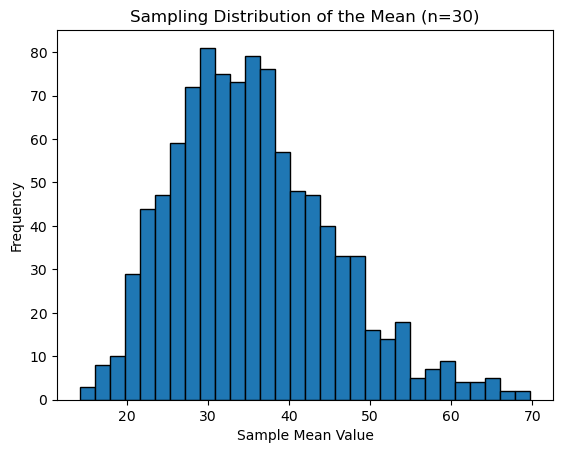

In [41]:
# now from only train dataset we select randomly sample and try to match to the original

# 1. Define parameters
number_of_samples = 1000
sample_size = 30
sample_means = []

# 2. Loop to generate the sampling distribution
for i in range(number_of_samples):
    # Take a random sample of 40 fares
    sample = test_fare.sample(n=sample_size, replace=True) 
    # Calculate the mean of that specific sample
    sample_means.append(sample.mean())

# 3. Visualize the result
plt.hist(sample_means, bins=30, edgecolor='black')
plt.title(f'Sampling Distribution of the Mean (n={sample_size})')
plt.xlabel('Sample Mean Value')
plt.ylabel('Frequency')
plt.show()

In [42]:
# comparing both therotical and our emperical (from sampling distribution)

# Convert the list to a numpy array so we can use .mean() and .var()
sample_means_arr = np.array(sample_means)


print(f" real or therotical mean :: {theoretical_mean}  real variance :  {theoretical_var} ")
print(f" from dist or emperical mean :: {sample_means_arr.mean()}  real variance :  {sample_means_arr.var() * sample_size} ")

 real or therotical mean :: 33.29547928134557  real variance :  2678.959737892894 
 from dist or emperical mean :: 35.52961265205254  real variance :  2873.6756665698376 


In [47]:
# so the interval with 95% confidence are
s_mean = sample_means_arr.mean()

# because std in sqrt of (variance^2/sample size)
s_std = sample_means_arr.std() / np.sqrt(sample_size)

low = s_mean - ( 2 * s_std)
high = s_mean + ( 2 * s_std)

print(f"the 95% confidence interval for the actual mean range are [ {low} , {high} ]")

the 95% confidence interval for the actual mean range are [ 31.95583428015796 , 39.103391023947125 ]


<Axes: ylabel='Density'>

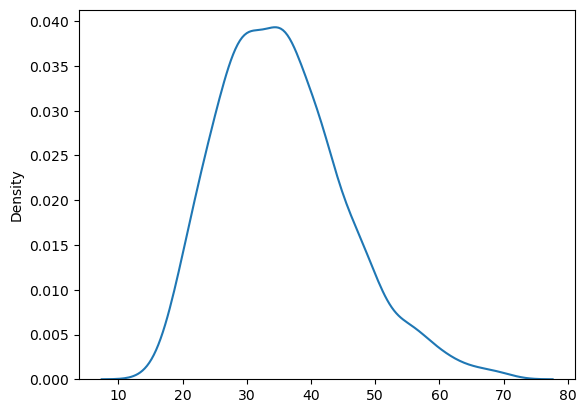

In [21]:
sns.kdeplot(sample_means_arr)

In [9]:
h

NameError: name 'h' is not defined

In [15]:
import numpy as np
from scipy import stats
import pandas as pd

# 1. Setup based on your experiment
num_samples = 200
sample_size = 30
samples = []
stds = []

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df = pd.concat([df_train, df_test])

# Collect data
for i in range(num_samples):
    x = df['Fare'].dropna().sample(sample_size).values
    samples.append(x.tolist())
    stds.append(x.std())

# 2. Calculate the 'Grand Mean' and the 'Average Standard Deviation'
grand_mean = np.mean(samples)
avg_std = np.mean(stds)

# 3. T-Procedure Parameters
# df (Degrees of Freedom) is n - 1
dof = sample_size - 1
# Get the T-critical value for 95% confidence
t_critical = stats.t.ppf(q=0.975, df=dof) 

# 4. Calculate Standard Error and Confidence Interval
# We use sample_size (30) here because we are looking at the 
# reliability of the individual samples of 30
standard_error = avg_std / np.sqrt(num_samples)

lower_limit = grand_mean - (t_critical * standard_error)
upper_limit = grand_mean + (t_critical * standard_error)

print(f"Degrees of Freedom: {dof}")
print(f"T-Critical Value: {t_critical:.3f}")
print(f"95% Confidence Interval: [{lower_limit:.2f}, {upper_limit:.2f}]")

Degrees of Freedom: 29
T-Critical Value: 2.045
95% Confidence Interval: [27.61, 41.38]


In [20]:
import numpy as np
from scipy import stats
import pandas as pd

# 1. Setup for a single experiment
sample_size = 100

# Load data
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df = pd.concat([df_train, df_test])

# 2. Collect exactly ONE sample (This is the "Single Sample")
# In the real world, you don't have a loop here
single_sample = df['Fare'].dropna().sample(sample_size).values

# 3. Calculate Sample Statistics
s_mean = np.mean(single_sample)
s_std = np.std(single_sample, ddof=1) # ddof=1 for sample standard deviation

# 4. T-Procedure Parameters
# Degrees of Freedom (dof) is n - 1
dof = sample_size - 1

# Get the T-critical value for 95% confidence
t_critical = stats.t.ppf(q=0.975, df=dof) 

# 5. Calculate Standard Error and Confidence Interval
# Standard Error for a single sample is (Sample Std / sqrt(n))
standard_error = s_std / np.sqrt(sample_size)

lower_limit = s_mean - (t_critical * standard_error)
upper_limit = s_mean + (t_critical * standard_error)

# 6. Report the results
print(f"Sample Mean: {s_mean:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"T-Critical Value: {t_critical:.3f}")
print(f"95% Confidence Interval for the population mean: [{lower_limit:.2f}, {upper_limit:.2f}]")

Sample Mean: 30.41
Degrees of Freedom: 99
T-Critical Value: 1.984
95% Confidence Interval for the population mean: [22.41, 38.40]


In [10]:
df['Fare'].mean()

np.float64(33.29547928134557)

# Hypothesis testing single t test

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

test_age = df_test[['Age']].squeeze()
train_age = df_train[['Age']].squeeze()

total_age = pd.concat([train_age, test_age])

population_age = total_age.dropna()
population_age.shape

(1046,)

In [33]:
# taking 25 samples
sample = population_age.sample(25)
print(sample[:5])

390    23.0
306    30.0
416    34.0
498    25.0
383    35.0
Name: Age, dtype: float64


### asumption
 - H0: mean age is 35
 - Ha: mean age is less than 35

### so given
 - population mean: 35
 - significance: 0.05
 - sample size : 25

In [34]:
# because sample size is less that 30 we can't use CLT
# we use shapiro wilk test for normality
from scipy.stats import shapiro

shapiro_age = shapiro(sample)
print(shapiro_age)

ShapiroResult(statistic=np.float64(0.952656423119318), pvalue=np.float64(0.28753208423891485))


In [35]:
import scipy.stats as stats
# now performing t test
pop_mean = 35

t_statistics, p_value = stats.ttest_1samp(sample, pop_mean)
print('t statics ', t_statistics)
print('p value', p_value/2)

t statics  -3.098652661414874
p value 0.002451674406125011


In [36]:
alpha = 0.05

if p_value < alpha:
    print("we reject the null hyphothesis")
else:
    print("we fail to reject the null hyphothesis")

we reject the null hyphothesis


In [37]:
# the actual mean
population_age.mean()

np.float64(29.881137667304014)

# Hypothesis testing 2 sample t test

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

total_age = pd.concat([df_train, df_test]).sample(1309)

pop_male = total_age[total_age["Sex"] == 'male']['Age'].dropna()
pop_female = total_age[total_age["Sex"] == 'female']['Age'].dropna()

print(pop_male.shape)
print(pop_female.shape)

(658,)
(388,)


In [50]:
# sampling
sample_male = pop_male.sample(25)
sample_female = pop_female.sample(25)

alpha = 0.05

### hyphothesis
 - H0: mean age of male and female has no difference
 - Ha: mean age of male is higher than female

In [51]:
pop_male.mean()

np.float64(30.58522796352584)

In [52]:
pop_female.mean()

np.float64(28.68708762886598)

# Chi square test

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('train.csv')

In [8]:
class_counts = df['Pclass'].dropna().value_counts().sort_index()
class_counts

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [10]:
print(class_counts)

Pclass
1    216
2    184
3    491
Name: count, dtype: int64
